In [2]:
import numpy as np
import pandas as pd
import os
import math
import re
import random
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegressionCV 
from sklearn.model_selection import train_test_split

In [ ]:
#collect data - metadata
data = []
data_dir = "20_newsgroups"
classes = os.listdir(data_dir)
for folder in classes:
    folder_path = f"{data_dir}/{folder}"
    if(os.path.exists(folder_path)):
        files = os.listdir(folder_path)
        print(len(files), folder_path)
        for file in files:
            file_path = f"{folder_path}/{file}"
            with open(file_path, "r", encoding="utf-8", errors="ignore" ) as f:
                text = f.read()
                data.append({"label": folder, "text": text})

In [15]:
## feature engineering - clean data
def clean_text(data):
    if not data:
        return []
    data = data.lower()
    data = re.sub(r'[^\w\s]', ' ', data)
    data = re.sub(r'\d+', ' ', data)
    data = re.sub(r'\s+', ' ', data).strip()
    token = data.split()
    token = [t for t in token if len(t) > 2]
    
    corpus_text = " ".join(token)
    return corpus_text, len(token)

#Count terms frequency for each document
def term_frequency(data):
    dictionary = dict.fromkeys(set(data), 0)
    for token in data:
        dictionary[token] +=1
    return dictionary

max_features = 0

for data_point in data:
    tokens, length = clean_text(data_point["text"])
    max_features = max(length, max_features)
    data_point["corpus_text"] = tokens

corpus = [dp["corpus_text"] for dp in data]
vectorizor = TfidfVectorizer(max_features=max_features, ngram_range=(1,2))
X = vectorizor.fit_transform(corpus)
y = [d["label"] for d in data]

In [5]:
model = LogisticRegressionCV(Cs=[0.001, 0.01, 0.1, 1, 10, 100]
,cv=3,dual=False,penalty="l2",solver="lbfgs",multi_class="multinomial",verbose=True,tol=1e-4,max_iter=1000)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.5,stratify=y,shuffle=True)
model.fit(X_train,y_train)

/home/nikunj/miniconda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1946: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   10.8s finished


,Cs,"[0.001, 0.01, ...]"
,fit_intercept,True
,cv,3
,dual,False
,penalty,'l2'
,scoring,None
,solver,'lbfgs'
,tol,0.0001
,max_iter,1000
,class_weight,None
,n_jobs,None


In [12]:
print(model.score(X_test,y_test))
# print(model.coef_)
# print(model.intercept_)
# print(model.C_)
# print(model.scores_)

0.9510951095109511


['rec.motorcycles', 'comp.sys.ibm.pc.hardware', 'comp.windows.x', 'comp.os.ms-windows.misc', 'rec.sport.baseball', 'sci.electronics', 'misc.forsale', 'sci.crypt', 'comp.graphics', 'sci.med', 'alt.atheism', 'talk.politics.guns', 'sci.space', 'talk.politics.misc', 'talk.politics.mideast', 'rec.autos', 'rec.sport.hockey', 'soc.religion.christian', 'comp.sys.mac.hardware', 'talk.religion.misc']


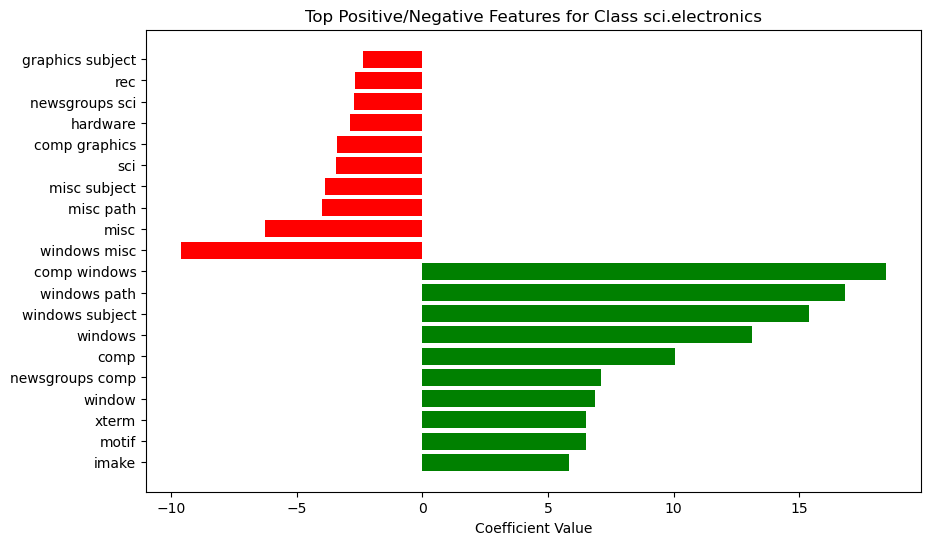

In [30]:
feature_names = vectorizor.get_feature_names_out()
top_n = 10
class_index = 5
print(classes)
coefs = model.coef_[class_index]
top_pos_indices = np.argsort(coefs)[-top_n:]
top_neg_indices = np.argsort(coefs)[:top_n]

plt.figure(figsize=(10,6))
plt.barh(range(top_n), coefs[top_pos_indices], color='green')
plt.barh(range(top_n, 2*top_n), coefs[top_neg_indices], color='red')
plt.yticks(range(2*top_n), 
           [feature_names[i] for i in list(top_pos_indices)+list(top_neg_indices)])
plt.xlabel("Coefficient Value")
plt.title(f"Top Positive/Negative Features for Class {classes[class_index]}")
plt.show()


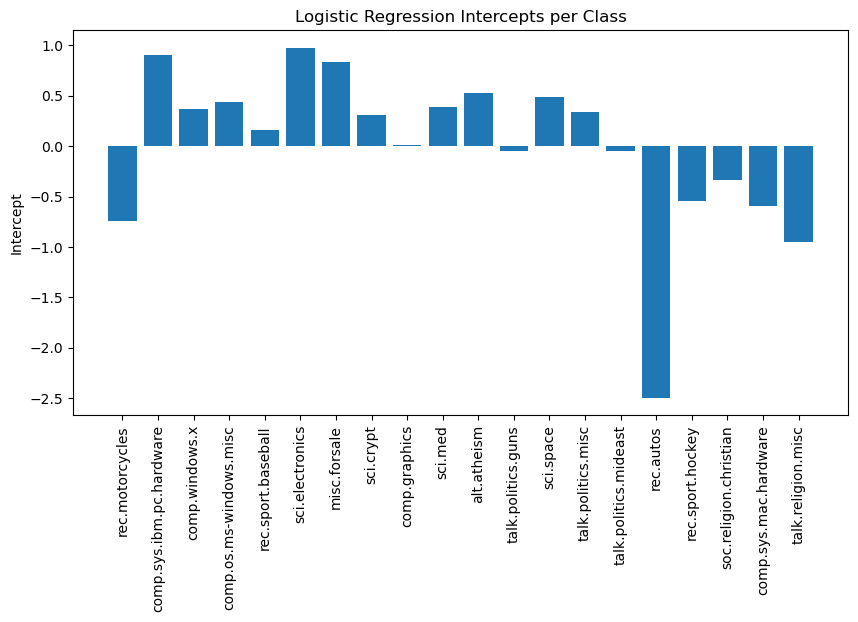

In [17]:
plt.figure(figsize=(10,5))
plt.bar(classes, model.intercept_)
plt.xticks(rotation=90)
plt.ylabel("Intercept")
plt.title("Logistic Regression Intercepts per Class")
plt.show()


In [7]:
confusion_matrix = np.zeros((20,20),dtype=int)
total_accuracy = 0
for index, doc in enumerate(X_test):
    prediction = model.predict(doc)
    i = classes.index(prediction[0])
    j = classes.index(y_test[index]) 
    confusion_matrix[i][j] +=1
    if (y_test[index] == prediction):
        total_accuracy+=1
print("Accuracy: ",total_accuracy / X_test.shape[0])

Accuracy:  0.9510951095109511


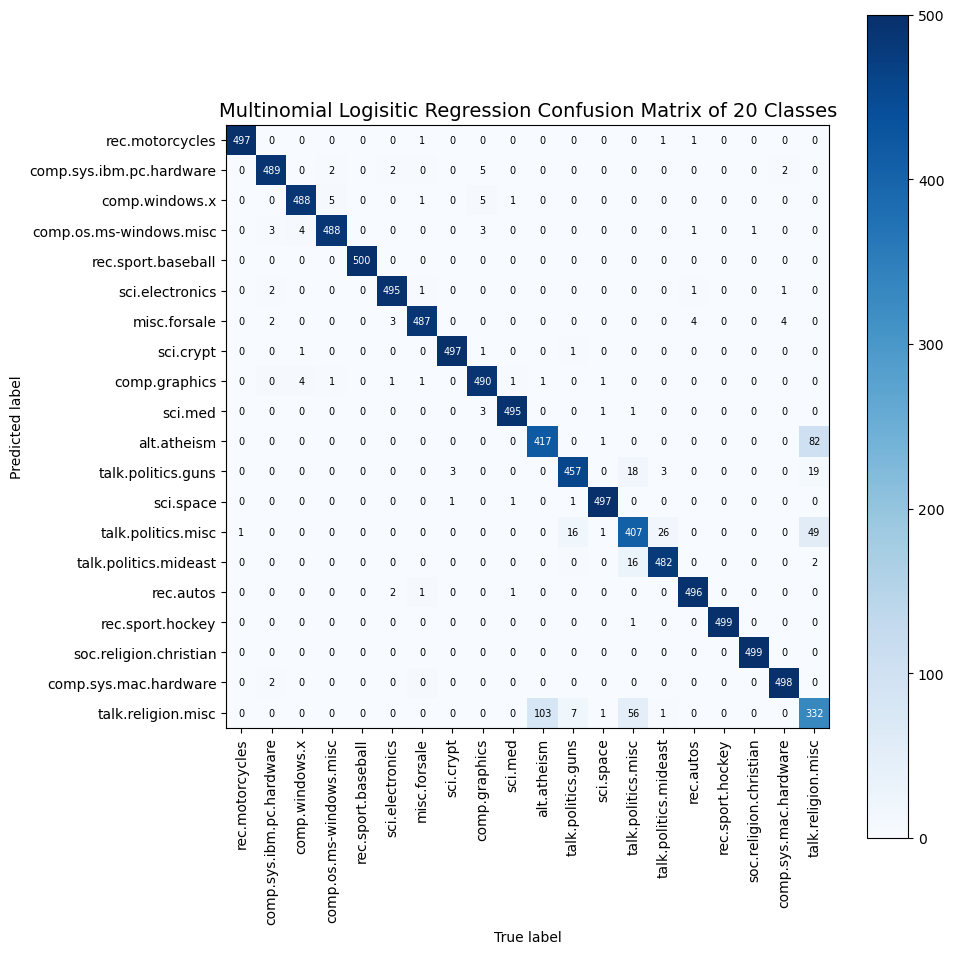

In [31]:
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(confusion_matrix, interpolation='nearest', cmap='Blues')

ax.set_title("Multinomial Logisitic Regression Confusion Matrix of 20 Classes", fontsize=14)
fig.colorbar(im, ax=ax)

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, rotation=90)
ax.set_yticklabels(classes)

thresh = confusion_matrix.max() / 2.
for i in range(confusion_matrix.shape[0]):
    for j in range(confusion_matrix.shape[1]):
        ax.text(i, j, f"{confusion_matrix[i, j]:d}",
                ha="center", va="center",
                color="white" if confusion_matrix[i, j] > thresh else "black",
                fontsize=7)

ax.set_ylabel('Predicted label')
ax.set_xlabel('True label')
plt.tight_layout()
plt.show()